# Batch correction on Chimaera data only

### Load packages

In [2]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(M3C)
})

### I/O

In [64]:
# chimaera
mixl_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/mlnt/3_QC/raw_counts.rds"
mixl_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/2_calledCells/genes.tsv"
mixl_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/mlnt/5_doubletDetection/meta.tab"

# out folder
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/Chimaera_only/"
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/Chimaera_only/plots/chim_"

### Read data

In [4]:
# load mixl data
mixl_counts = readRDS(mixl_data_in)
mixl_genes = read.table(mixl_genes_in, stringsAsFactors = F)
mixl_meta = read.table(mixl_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mixl_meta$cell <- paste0('chim_', mixl_meta$cell)
# annotate mixl counts
rownames(mixl_counts) = mixl_genes[,1] #ensembl
colnames(mixl_counts) = mixl_meta$cell

In [6]:
# create SCE object from mixl_count
big_sce <- SingleCellExperiment(assays = list("counts" = mixl_counts))
saveRDS(big_sce, file = paste0(out_folder,"mixl_sce.rds"))

In [7]:
# rename all to big_ in order to use other codes without changing names
big_meta <- mixl_meta

In [8]:
### quality filter
# extract cells to keep
keep <- big_meta %>% filter(stripped == FALSE & doublet == FALSE) %>% .$cell
# keep only those cells in big_sce
saveRDS(big_sce, file = paste0(out_folder,"mixl_sce_before_QC.rds"))
big_sce <- big_sce[, keep]
# save big_sce
saveRDS(big_sce, file = paste0(out_folder,"mixl_sce.rds"))

# save meta before cleaning
write.table(big_meta, file = paste0(out_folder,"mixl_meta_before_QC.tab"), row.names = F, col.names = T, quote = F, sep = "\t")
# clean meta
big_meta <- big_meta %>% filter(stripped == FALSE & doublet == FALSE)
# save meta after cleaning
write.table(big_meta, file = paste0(out_folder,"mixl_meta.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [9]:
# confirm SCE and metadata still overlap
summary(big_meta$cell == colnames(big_sce))

   Mode    TRUE 
logical   37208 

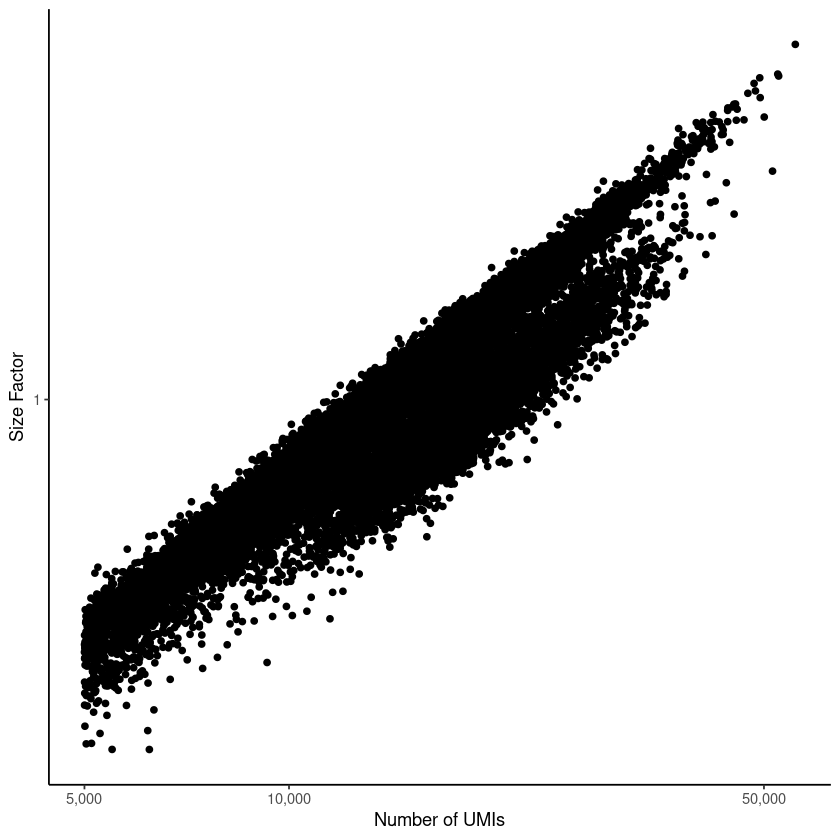

In [10]:
### Normalize
# calculate sizefactors
clusts = as.numeric(quickCluster(big_sce, method = "igraph", min.size = 100, BPPARAM = mcparam))
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
big_sce = computeSumFactors(big_sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)
write.table(sizeFactors(big_sce), quote = F, col.names = F, row.names = F, file = paste0(out_folder,"sizefactors_big.tab"))

lib.sizes = Matrix::colSums(counts(big_sce))
ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(big_sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor") + 
    theme_classic()

In [11]:
# Normalize
sfs = read.table(paste0(out_folder,"sizefactors_big.tab"), stringsAsFactors = F)[,1]
sizeFactors(big_sce) = sfs
big_sce = scater::logNormCounts(big_sce)

# save normalized sce
saveRDS(big_sce, file = paste0(out_folder,"mixl_sce_norm.rds"))

In [13]:
### HVGs
big_sce <- readRDS(paste0(out_folder, "mixl_sce_norm.rds"))
# ygenes
ygenes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/ygenes.tab"

# load genes
ychr_e = read.table(ygenes_in, stringsAsFactors = F)[,1]
genes_meta = read.table(mixl_genes_in, stringsAsFactors = F) # changed
rownames(genes_meta) = genes_meta$V1

# filter sex genes (Xist + ygenes)
paste0('genes before filtering: ', length(rownames(big_sce)))
big_sce   <- big_sce[!rownames(big_sce) %in% c('ENSMUSG00000086503', ychr_e),]
paste0('genes after filtering: ', length(rownames(big_sce)))


p.val_th = 0.05 # p-value threshold

# determine top HVGs
dec <- modelGeneVar(big_sce)
hvg_p <- getTopHVGs(dec, fdr.threshold = p.val_th)
paste0('number of HVGs based on P value: ', length(hvg_p))
hvg_n <- getTopHVGs(dec, n = 3000)

# save
write.csv(hvg_p, file =  paste0(out_folder,"mixl_hvgs_p.csv"))
write.csv(hvg_n, file =  paste0(out_folder,"mixl_hvgs_3000.csv"))

[1] "genes before filtering: 31053"

[1] "genes after filtering: 30319"

[1] "number of HVGs based on P value: 1213"

In [14]:
### Batch correction
BPPARAM = SerialParam()

# I/O
big_sce <- readRDS(paste0(out_folder, "mixl_sce_norm.rds"))
big_meta = read.table(paste0(out_folder,"mixl_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
hvgs = read.csv(paste0(out_folder,"mixl_hvgs_3000.csv"))$x

#### Cosine normalisation ##### 
# add metadata combining stage & sample
big_meta$comb <- paste0(big_meta$stage, "_", big_meta$sample)

# extract counts for each combination
mat_temp = logcounts(big_sce)
mat = mat_temp[hvgs,]

# seperate count matrices based on combination
comb <- list()
for(i in unique(big_meta$comb)){
    comb[[i]] <- mat[, big_meta$comb == i]
}
paste0('nr of combinations: ', length(comb))

# cosine normalize
comb_cos <- list()
for(i in 1:length(comb)){
    comb_cos[[i]] <- cosineNorm(comb[[i]])
}

######## from here on everything takes a while so may be better to run in Rscript rather than notebook
#### calculate PCs #####
big_pca = multiBatchPCA(comb_cos ,BPPARAM = BPPARAM,d = 50)

# save
saveRDS(big_pca, file=paste0(out_folder, 'uncorrected_PCs_multibatch.rds'))
big_pca <- do.call(rbind, big_pca)
saveRDS(big_pca, file=paste0(out_folder, 'uncorrected_PCs.rds'))

[1] "nr of combinations: 6"

In [15]:
# Reload data
big_pca <- readRDS(paste0(out_folder, 'uncorrected_PCs.rds'))
big_meta = read.table(paste0(out_folder,"mixl_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [16]:
### There is only 1 timepoint so this code is a bit overkill


#### reducedMNN preparation ##### (run in next cell)
set.seed(42)
# over several iterations 

# order of batch corrections --> input chimaera as seperate timepoint to make looping easier
#### This way chimaera's will still be batch corrected separately from atlas.
order_df = big_meta[!duplicated(big_meta$sample), c("stage", "sample")]
order_df$ncells = sapply(order_df$sample, function(x) sum(big_meta$sample == x))
order_df$stage = factor(order_df$stage,
                          levels = rev(c("E8.5"))) # only 1 timepoint this time
                         
order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
order_df$stage = as.character(order_df$stage)
order_df$comb <- paste0(order_df$stage, "_", order_df$sample)

# defenitions for creating nested lists                         
timepoints = big_meta$stage
samples = big_meta$sample
timepoint_order = order_df$stage
sample_order = order_df$sample

#create nested list
  pc_list = lapply(unique(timepoints), function(tp){
    sub_pc = big_pca[timepoints == tp, , drop = FALSE]
    sub_samp = samples[timepoints == tp]
    list = lapply(unique(sub_samp), function(samp){
     sub_pc[sub_samp == samp, , drop = FALSE]
    })
    names(list) = unique(sub_samp)
    return(list)
  })

  names(pc_list) = unique(timepoints)

  #arrange to match timepoint order
  pc_list = pc_list[order(match(names(pc_list), timepoint_order))]
  pc_list = lapply(pc_list, function(x){
    x[order(match(names(x), sample_order))]
  })

# create if statement for following numbers in next cell:
print('create if statement for following values: ')
    for(i in 1:length(pc_list)){
    print(length(pc_list[[i]]))
}

[1] "create if statement for following values: "
[1] 6


In [17]:
# reducedMNN within timepoints
# reducedMNN is too stupid to understand looping over list so each list element has to be inputted as seperate object
# done with if statement so you don't have to write a seperate line for each nested list
corrected_pcs <- list()
for(i in 1:length(pc_list)){
    if(length(pc_list[[i]]) == 1){
        corrected_pcs[[i]] <- unlist(pc_list[[i]][[1]])
    }
    if(length(pc_list[[i]]) == 2){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 3){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 4){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 5){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]], pc_list[[i]][[5]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 6){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]], pc_list[[i]][[5]], pc_list[[i]][[6]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 10){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]], pc_list[[i]][[5]], pc_list[[i]][[6]],pc_list[[i]][[7]], pc_list[[i]][[8]], pc_list[[i]][[9]],pc_list[[i]][[10]],BPPARAM = SerialParam())$corrected
    }
}

saveRDS(corrected_pcs, file=paste0(out_folder, 'corrected_PCs_time_multibatch.rds'))
correct_complete = do.call(rbind, corrected_pcs)
write.csv(correct_complete, paste0(out_folder, 'corrected_pc_complete.csv'))

In [18]:
# order pcs according to metadata
big_meta = read.table(paste0(out_folder,"mixl_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
cells <- big_meta$cell
keyDF <- data.frame(key=cells,weight=1:length(cells))
correct_complete <- as.data.frame(correct_complete)
correct_complete$cell <- rownames(correct_complete)
merged <- merge(correct_complete,keyDF,by.x='cell',by.y='key',all.x=T,all.y=T)
correct_complete <- merged %>% arrange(weight)
correct_complete$weight <- NULL
rownames(correct_complete) <- correct_complete$cell
correct_complete$cell <- NULL

write.csv(correct_complete, paste0(out_folder, 'corrected_pc_complete.csv'))

In [32]:
# Load in data
big_meta = read.table(paste0(out_folder,"mixl_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
pca_before = as.data.frame(readRDS(paste0(out_folder, 'uncorrected_PCs.rds')))
pca_before$cell <- rownames(pca_before)
pca_after = as.data.frame(read.csv(paste0(out_folder, 'corrected_pc_complete.csv'), header=T, row.names=1,sep=","))
pca_after$cell <- rownames(pca_after)

In [35]:
# add metadata to PCs
pca_before <- merge(pca_before, big_meta, by='cell')
rownames(pca_before) <- pca_before$cell
pca_after <- merge(pca_after, big_meta, by='cell')
rownames(pca_after) <- pca_after$cell

In [36]:
### whole object
# before correction
pca_before$origin <- sapply(strsplit(pca_before$cell,"_"), `[`, 1)
pca_before <- pca_before %>% select(2:51)
pca_before_umap = umap(t(pca_before))$data
pca_before_umap <- as.data.frame(pca_before_umap)
colnames(pca_before_umap) <- c('umap1','umap2')
pca_before_umap$cell <- rownames(pca_before)
pca_before_umap <- merge(pca_before_umap, big_meta, by='cell')
# write
write.csv(pca_before_umap, paste0(out_folder, 'umap_before_correction.csv')) 
print('finished third umap')

# after correction
pca_after$origin <- sapply(strsplit(pca_after$cell,"_"), `[`, 1)
pca_after <- pca_after %>% select(2:51)
pca_after_umap = umap(t(pca_after))$data
pca_after_umap <- as.data.frame(pca_after_umap)
colnames(pca_after_umap) <- c('umap1','umap2')
pca_after_umap$cell <- rownames(pca_after)
pca_after_umap <- merge(pca_after_umap, big_meta, by='cell')
# write
write.csv(pca_after_umap, paste0(out_folder, 'umap_after_correction.csv')) 
print('finished fourth umap')

***UMAP wrapper function***

running...

done.



[1] "finished third umap"


***UMAP wrapper function***

running...

done.



[1] "finished fourth umap"


In [33]:
# load in data
pca_before_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_before_correction.csv'), header=T, row.names=1,sep=","))
pca_after_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction.csv'), header=T, row.names=1,sep=","))
pca_after_umap$sample = paste0('mixl_', pca_after_umap$sample)
pca_after_umap$stage = paste0('E', pca_after_umap$stage)
big_meta <- read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/big_meta_mapping.tab", header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [42]:
pca_after_umap <- merge(pca_after_umap, big_meta, by=c('cell', 'barcode', 'sample', 'stage', 'stripped', 'doublet'), all.x=TRUE)

In [62]:
# colors
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")

# whole object
p5 <- ggplot(pca_before_umap, aes(umap1, umap2, color=as.factor(sample))) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('whole object before correction, color = sample')
p6 <- ggplot(pca_after_umap, aes(umap1, umap2, color=sample)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('whole object after correction, color = sample')

p7 <- ggplot(pca_after_umap, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 1) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) +
    ggtitle('whole object after correction, color = tomato')
p8 <- ggplot(pca_after_umap, aes(umap1, umap2, color=celltype.mapped)) +
    geom_point(alpha=0.5, size = 1) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
    theme(legend.position = "none") +
    ggtitle('whole object after correction, color = celltype')


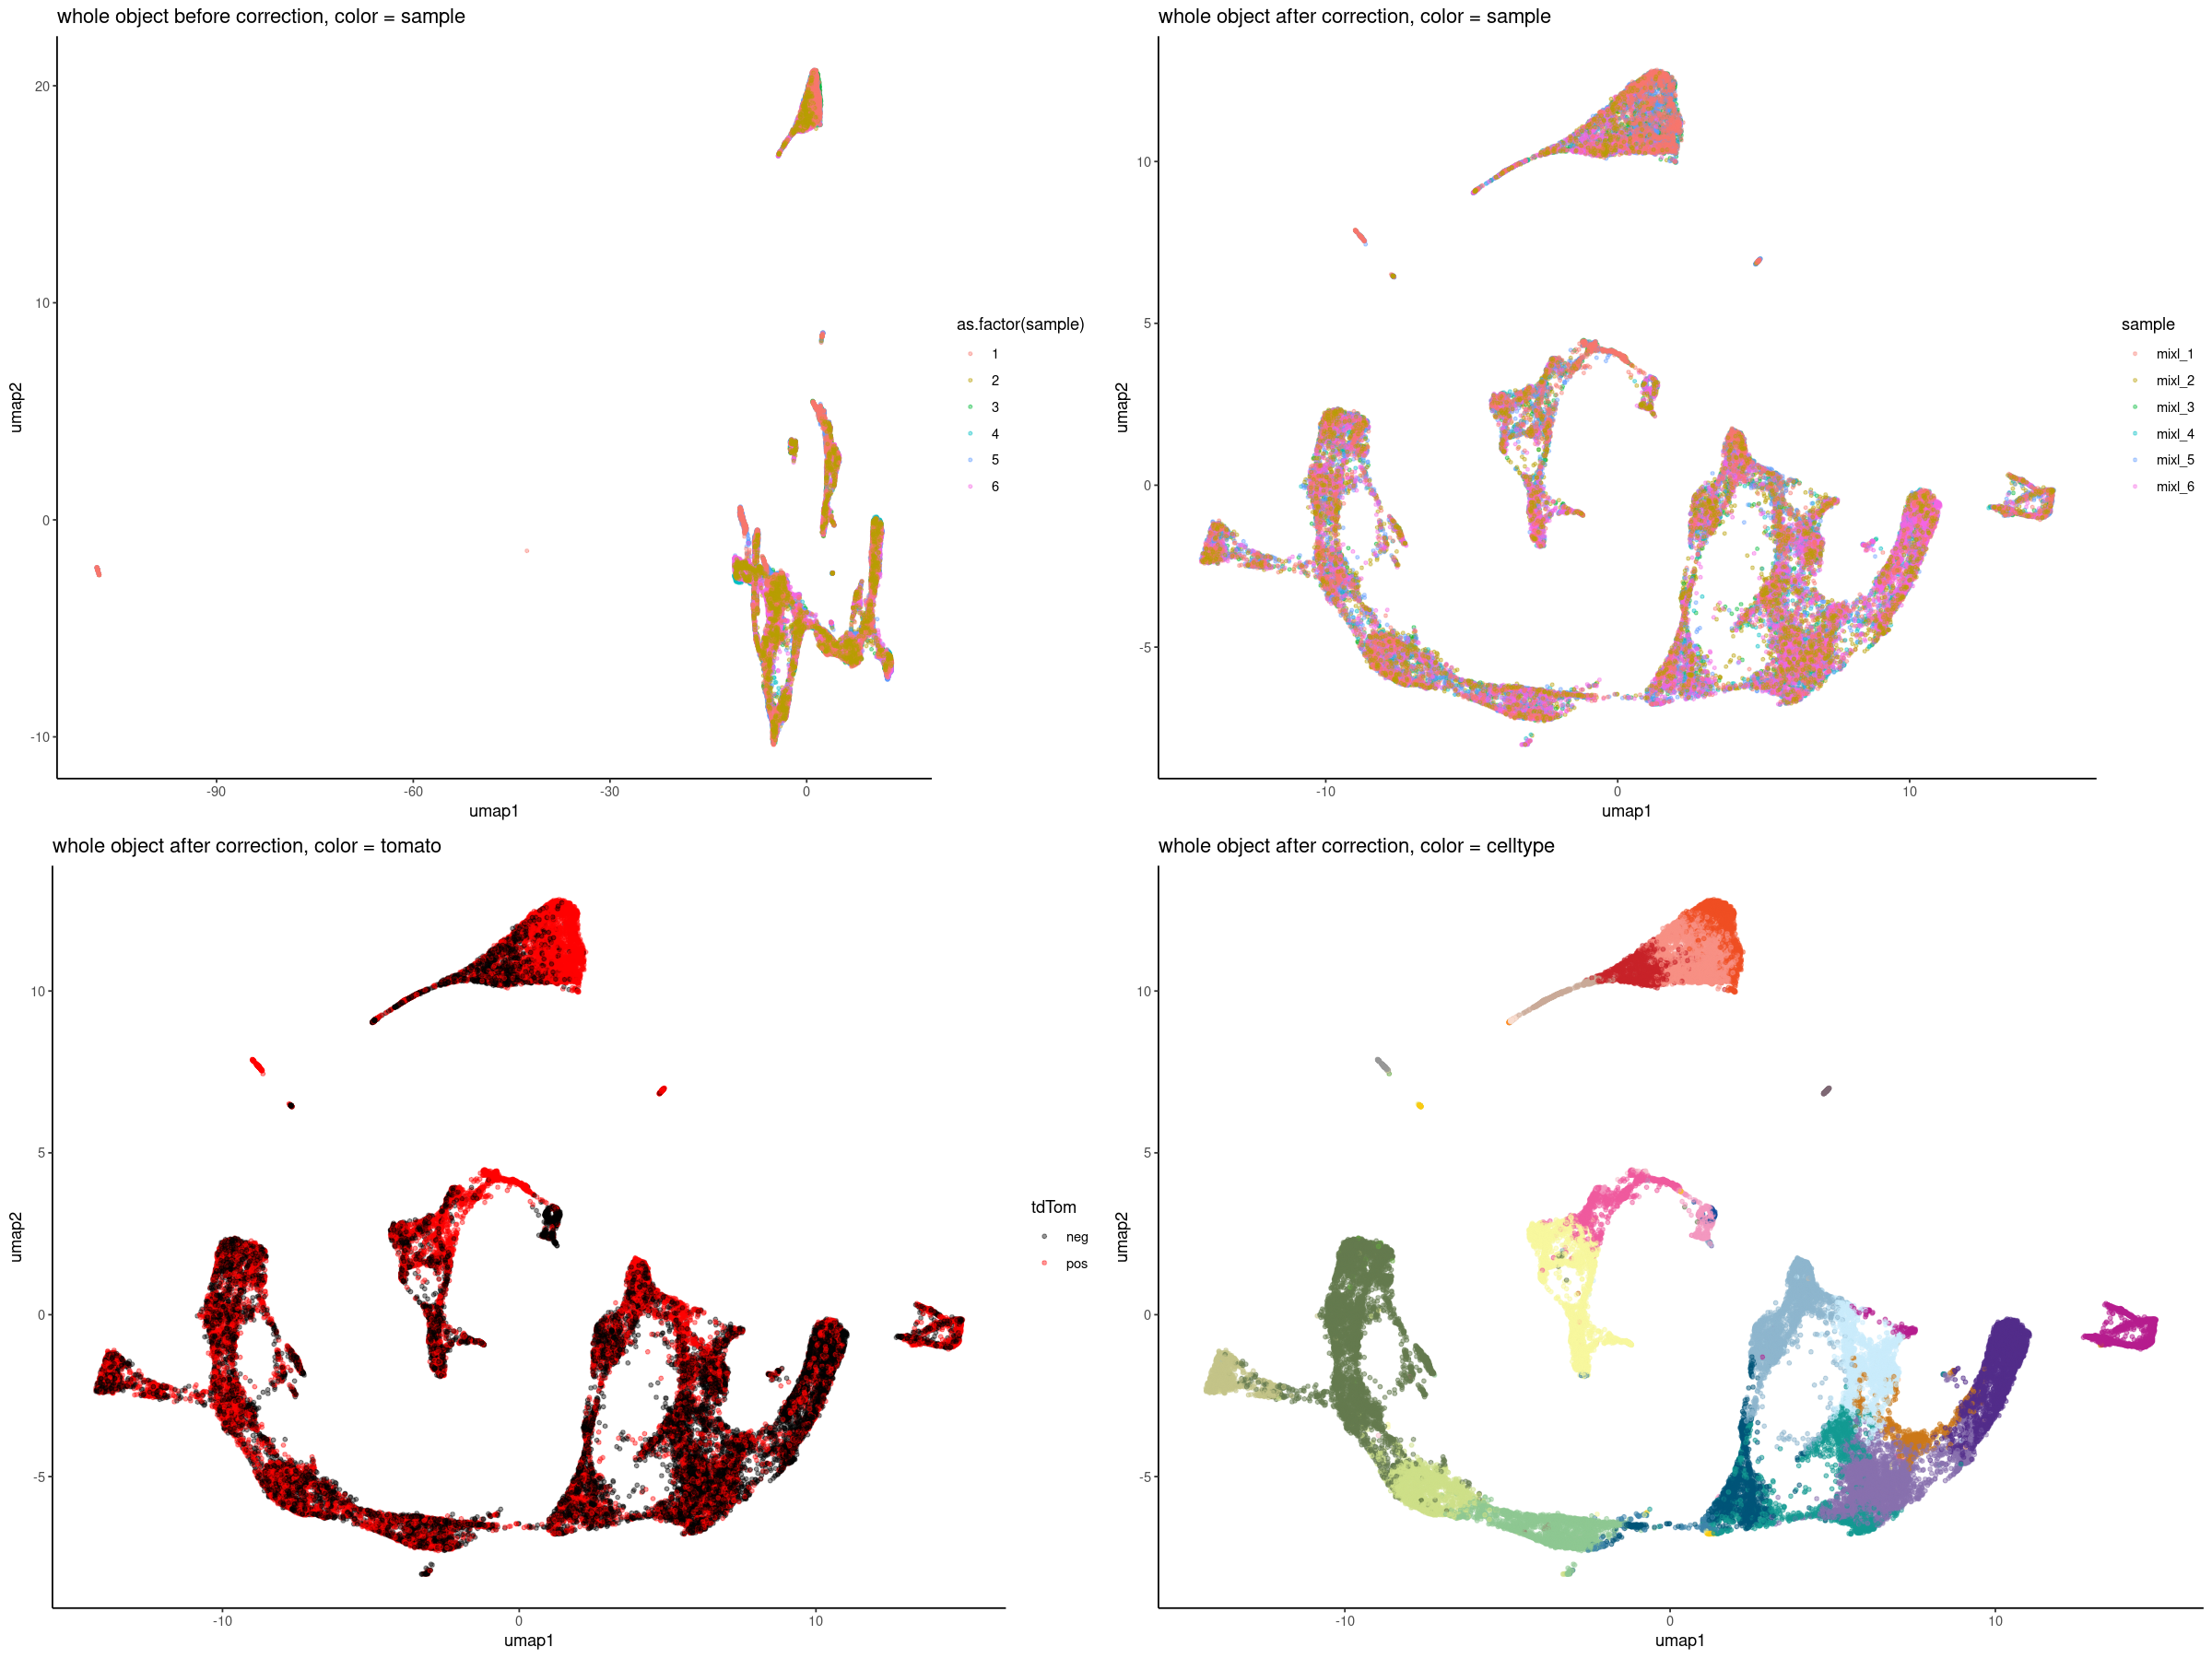

In [63]:
options(repr.plot.width = 20, repr.plot.height = 15)
    grid.arrange(p5, p6, p7, p8, nrow =2)

In [68]:
png(paste0(plot_folder, "umap.png"), height=1000, width=1500)
    grid.arrange(p5, p6, p7, p8, nrow =2)
dev.off()

png 
  2